## Homework 1 - Phase I & II Analysis Using Shewhart $\bar{X}$ and R/s Charts
### Dr. Austin Brown
### Kennesaw State University

**DUE: September 19, 2026 via D2L**

## Instructions:

A company called Blue Ridge Filament Co (BRFC) manufactures 1.75 mm PLA filament for 3D printers, selling to both hobbyist and small-manufacturing customers. Over the last quarter, customer support tickets describing clogging, stringing, and inconsistent print layers have risen sharply, and BRFC recently lost a wholesale account to a competitor over “inconsistent quality.” The plant manager has asked your quality control team to investigate Extruder Line 3, the line most frequently named in the complaint data, and to determine whether the line is running in a state of statistical control. This line is about six months away from needing its heating element replaced, but it could be replaced sooner if necessary.

The plant manager is particularly interested in the filament diameter produced (mm), measured inline by a laser micrometer as each spool is produced. Diameter that runs too thin causes under-extrusion and stringing; diameter that runs too thick causes jams and clogs in customers' print heads. Filament diameter is treated as a continuous, normally-distributed quality characteristic for this assignment.

Your team pulls a baseline (Phase I) sample of production data from Line 3: 5 spools sampled at random each week, for 25 consecutive weeks. After validating statistical control and process capability, the team can establish an ongoing monitoring plan for Phase II analysis.

## Key Specifications

| Quantity | Value |
|---|---|
| Target diameter | 1.750 mm |
| Lower Specification Limit (LSL) | 1.700 mm |
| Upper Specification Limit (USL) | 1.800 mm |
| Subgroup size (n) | 5 spools per week |
| Phase I subgroups (m) | 25 weeks |
| Phase II subgroups | 20 weeks |

## Define & Measure

### Q1: Briefly describe the purpose of this analysis

In short: Identify if the diameter is statistically out of control and causing the inconsistent results customers are complaining about.

In long: The purpose of the analysis is to see if the diameter of the PLA filaments for the 3D printers is consistently being produced. The plan is to identify if the diameter of the PLA filament being produced is in statistical control specifically looking at Extruder Line 3. We are looking at the sample produced (n=5, m=25) to see the diameter measurements are within a expected process limits. Once we have identified if the daimeters are in statistical control we then can evaluate our controls capabiliity. If we do not see that the diameters are outside of statistical control and our controls are effective then we will have to expand our search for the reason customers are complaining about inconsistent printing layers maybe the calibration of the laser micrometer is giving inconsistent measurements and we need to audit that process as well. If they are outside of statistical control we then can ask why and by how much. It could be that the heating element needs to be replaced sooner.

### Q2: Identify the quality characteristic your team will monitor, classify its units and measurement scale.
Diameter of PLA filaments in milimeters using the laser micrometer which is a quantitative variable.


### Q3: Briefly describe why a Shewhart $\bar{X}$ and $R/s$ chart would be appropriate in this scenario. What are its limitations?

The Shewhart $\bar{X}$ and $R/s$ chart are appropriate for the scenario because the distribution is normal and we are looking at a continuous variable. These charts are great at visualizing process location and variability and that is very important in manufacturing process. The $\bar{X}$ can identify if the mean is stable over time and the $R/s$ chart can look at the variability. These can identify issues of certain causes in timed segements. The limitations is that the charts can identify if the diameter is statistically in control but cannot identify if that is the cause of the inconsistent printing customers have complained about. Also because it is a time window only 25 weeks it may not be able to show the degredation of the heating element or catch other small shifts as effectively.

## Analyze

### Q4: Read the Phase I data into R. Calculate and report the estimated process mean and standard deviation using both the $R$ and $s$ methods.


In [5]:
## Q4 Code ##
# library
install.packages("tidyverse")
install.packages("readxl")
install.packages("qcc")
library(tidyverse)
library(readxl)
library(qcc)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [11]:
#upload code
PLA_df <- read_excel("/content/FilamentDiameter_PhaseI.xlsx")

PLA_df |> glimpse()

Rows: 25
Columns: 6
$ Subgroup <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18…
$ Meas1    <dbl> 1.759712, 1.752064, 1.755094, 1.763434, 1.751915, 1.746336, 1…
$ Meas2    <dbl> 1.742690, 1.733264, 1.745186, 1.746130, 1.757228, 1.769405, 1…
$ Meas3    <dbl> 1.771452, 1.767347, 1.753372, 1.747787, 1.745419, 1.752795, 1…
$ Meas4    <dbl> 1.758564, 1.761277, 1.763998, 1.747608, 1.755608, 1.750858, 1…
$ Meas5    <dbl> 1.755669, 1.744550, 1.745075, 1.748262, 1.742620, 1.737254, 1…


In [16]:
#plot X_bar chart
phase1_xbar <- qcc(PLA_df |> select(-`Subgroup`),
                   type = "xbar",
                   plot = FALSE)

phase1_xbar$center
phase1_xbar$std.dev

[1] 1.754017

[1] 0.01144864

Process mean = 1.754017, standard deviation = 0.01144864

In [17]:
phase1_r <- qcc(PLA_df |> select(-`Subgroup`),
                 type = "R",
                 plot = FALSE)

phase1_r$center
phase1_r$std.dev

[1] 0.02662954

[1] 0.01144864

Process range = 0.02662954, standard deviation = 0.01144864


### Q5: Construct a Phase I $R$ chart. Does the chart show evidence of statistical control? If not, identify the out-of-control subgroup(s) by number and provide a contextual explanation as to why these OOC points may have been observed, omit these points, and replot the chart until statistical control is observed.

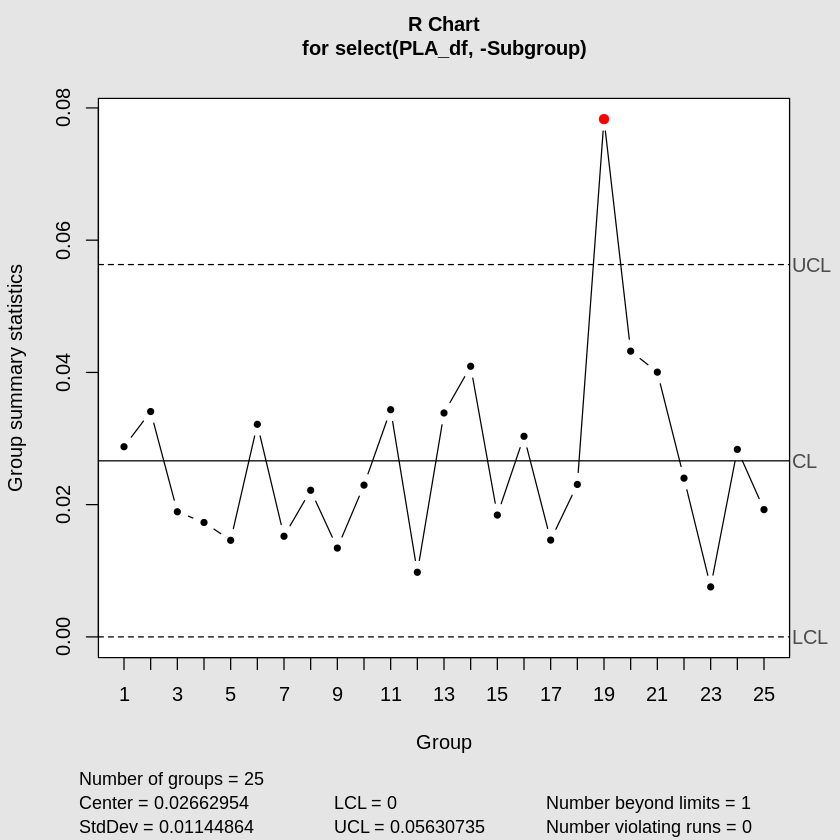

In [19]:
## Q5 Code ##
phase1_r <- qcc(PLA_df |> select(-`Subgroup`),
                 type = "R",
                 plot = TRUE)

In [37]:
phase1_r$violations

PLA_df |> glimpse()
PLA_df |> filter(Subgroup == 19)

$beyond.limits
[1] 19

$violating.runs
numeric(0)

Rows: 25
Columns: 6
$ Subgroup <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18…
$ Meas1    <dbl> 1.759712, 1.752064, 1.755094, 1.763434, 1.751915, 1.746336, 1…
$ Meas2    <dbl> 1.742690, 1.733264, 1.745186, 1.746130, 1.757228, 1.769405, 1…
$ Meas3    <dbl> 1.771452, 1.767347, 1.753372, 1.747787, 1.745419, 1.752795, 1…
$ Meas4    <dbl> 1.758564, 1.761277, 1.763998, 1.747608, 1.755608, 1.750858, 1…
$ Meas5    <dbl> 1.755669, 1.744550, 1.745075, 1.748262, 1.742620, 1.737254, 1…


Subgroup,Meas1,Meas2,Meas3,Meas4,Meas5
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
19,1.760588,1.728227,1.725406,1.803716,1.800031


The R chart shows that the subgroup run 19 variablity was outside the upper control limit. These measurements could be because of a measuring error or an issue we are seeing with the machine such as the heating element.


Rows: 24
Columns: 6
$ Subgroup <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18…
$ Meas1    <dbl> 1.759712, 1.752064, 1.755094, 1.763434, 1.751915, 1.746336, 1…
$ Meas2    <dbl> 1.742690, 1.733264, 1.745186, 1.746130, 1.757228, 1.769405, 1…
$ Meas3    <dbl> 1.771452, 1.767347, 1.753372, 1.747787, 1.745419, 1.752795, 1…
$ Meas4    <dbl> 1.758564, 1.761277, 1.763998, 1.747608, 1.755608, 1.750858, 1…
$ Meas5    <dbl> 1.755669, 1.744550, 1.745075, 1.748262, 1.742620, 1.737254, 1…


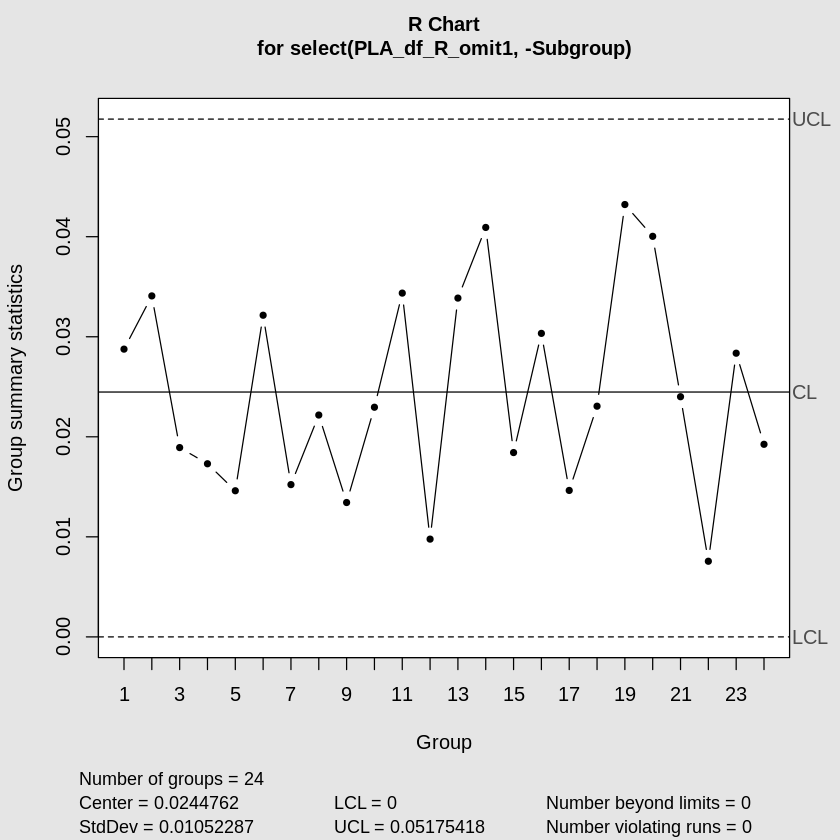

In [42]:
PLA_df_R_omit1<-PLA_df |> filter(Subgroup != 19)
PLA_df_R_omit1 |> glimpse()

phase1_r_omit1 <- qcc(PLA_df_R_omit1 |> select(-`Subgroup`),
                 type = "R",
                 plot = TRUE)

After removing sample run 19 statistical control is observed.

### Q6: Using only the subgroups retained after Q5, construct the Phase I $\bar{X}$ chart. Does the chart show evidence of statistical control? If not, identify the out-of-control subgroup(s) by number and provide a contextual explanation as to why these OOC points may have been observed, omit these points, and replot the chart until statistical control is observed.

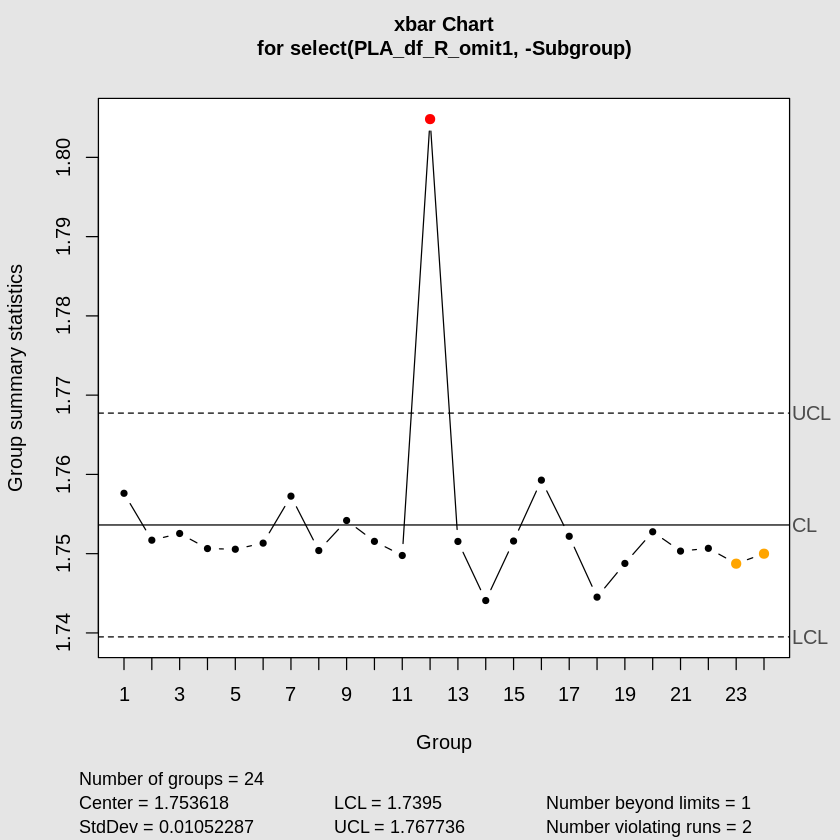

In [44]:
## Q6 Code ##
phase1_xbar_omit1 <- qcc(PLA_df_R_omit1 |> select(-`Subgroup`),
                   type = "xbar",
                   plot = TRUE)

In [45]:
phase1_xbar_omit1$violations

$beyond.limits
[1] 12

$violating.runs
[1] 23 24

The $\bar{X}$ shows that there is one point that is outside of statistical control limits run 12. This has indicated that the average diameter for run 12 is above the control limits. This could be because of an error with the heating element needing replacement or issue with the measuring laster.

Warning message:
“There was 1 warning in `filter()`.
ℹ In argument: `Subgroup != c(19, 12)`.
Caused by warning in `Subgroup != c(19, 12)`:
! longer object length is not a multiple of shorter object length”


Rows: 23
Columns: 6
$ Subgroup <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17, 18, 20…
$ Meas1    <dbl> 1.759712, 1.752064, 1.755094, 1.763434, 1.751915, 1.746336, 1…
$ Meas2    <dbl> 1.742690, 1.733264, 1.745186, 1.746130, 1.757228, 1.769405, 1…
$ Meas3    <dbl> 1.771452, 1.767347, 1.753372, 1.747787, 1.745419, 1.752795, 1…
$ Meas4    <dbl> 1.758564, 1.761277, 1.763998, 1.747608, 1.755608, 1.750858, 1…
$ Meas5    <dbl> 1.755669, 1.744550, 1.745075, 1.748262, 1.742620, 1.737254, 1…


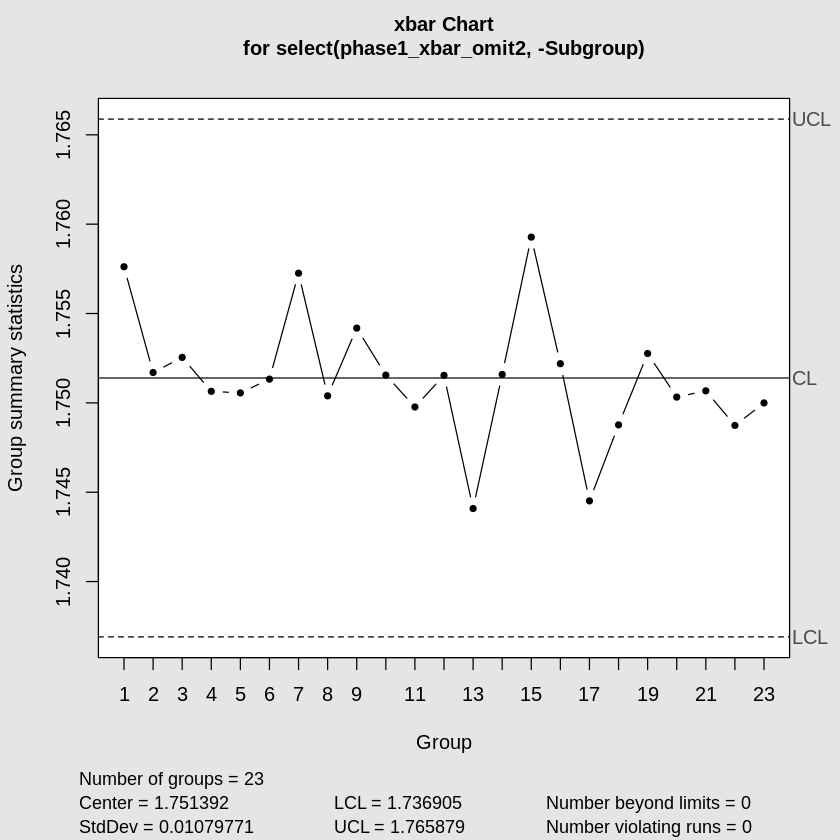

In [47]:
phase1_xbar_omit2<-PLA_df |> filter(Subgroup != c(19,12))
phase1_xbar_omit2 |> glimpse()

phase1_x_omit2 <- qcc(phase1_xbar_omit2 |> select(-`Subgroup`),
                 type = "xbar",
                 plot = TRUE)

After omitting run 12 and the run 19 from the previous question the process appears to be in statistical control.

### Q7: Repeat the same process in Q4 - Q6 now using the $s$ chart instead of the $R$ chart

In [ ]:
## Q7 Code ##

### Q8: Using your final Phase I estimates of the process mean and process standard deviation (using $s$ method), perform a process capability analysis against the specification limits given about. Report and interpret $FNC$, $C_p$, $C_{pk}$, and $C_{pm}$. Is the process capable of meeting specification? Is it well-centered?

In [ ]:
## Q8 Code ##

## Improve

### Q9: Briefly provide a contextual explanation as to leaving OOC points in the Phase I calculation of the control limits after identifying an assignable cause is not advisable.

## Control

### Q10: Read in the Phase II data into R. Using the finalized Phase I center line and control limits from Q7, construct the Phase II $\bar{X}$ chart. Do any subgroups plot outside the control limits?

In [ ]:
## Q10 Code ##

### Q11: Construct a Phase II $s$ chart. Do any subgroups plot outside the control limits?

In [ ]:
## Q11 Code ##

### Q12: Provide an overview of the results that the plant manager can provide the Vice President of Operations. Do they need to completely overhaul line 3 or is it salvagable?